## Hyperparameters

Adjust **`n_qubits`**, **`n_samples`**, **`n_layers`**, **`shots`**, step count, noise. Leave **`smooth_lambda = 0`** unless the target is smooth and you want less bin-to-bin wiggle.

In [119]:
import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

from qfun.encode import grid_x
from qfun.simulate import counts_to_distribution

# --- experiment knobs ---
rng = np.random.default_rng(42)
n_qubits = 5  # circuit wires and log2(grid cells); not the data sample count
n_samples = 50_000  # i.i.d. draws used to build the target histogram on that grid
n_layers = 2
shots = 100000  # shots per training eval (unrelated to n_samples)
n_steps = 400
adam_stepsize = 0.01
smooth_lambda = 0.0  # set >0 only for smooth p*; sharp targets need 0 (see intro)
noise_sigma = 0.05  # Gaussian noise on the synthetic signal
target_eps = 1e-9  # floor before normalizing target distribution
interval = (-1.0, 1.0)
a, b = interval

wires = list(range(n_qubits))
dim = 2**n_qubits

## Target distribution on the grid

`x_grid` is the QFun grid (\(2^{n_\mathrm{qubits}}\) points on \([a,b]\)). The target **`p_target`** comes from **`n_samples`** Monte Carlo draws: for each draw, sample \(x\) uniformly on \([a,b]\), weight \(\max(x^2+\epsilon_\mathrm{noise},0)\), add that weight to the bin that contains \(x\), then normalize.

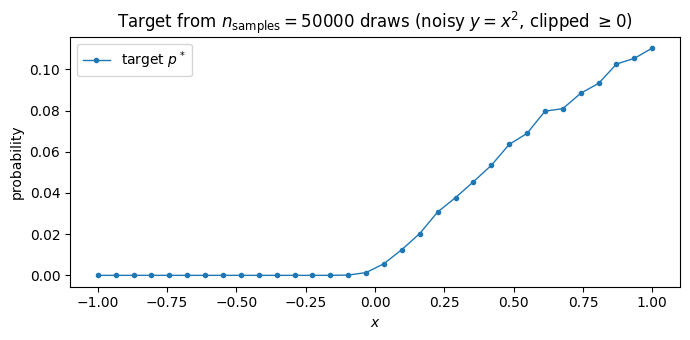

In [120]:
x_grid = grid_x(a, b, n_qubits)
x_samp = rng.uniform(a, b, size=n_samples)
noise = rng.normal(0.0, noise_sigma, size=n_samples)
w = np.maximum(np.sin(x_samp) + noise, 0.0) + target_eps
idx = np.floor((x_samp - a) / (b - a) * dim).astype(np.int64)
idx = np.clip(idx, 0, dim - 1)
bin_weights = np.bincount(idx, weights=w, minlength=dim)
p_target = bin_weights / bin_weights.sum()

assert p_target.shape == (dim,)
assert np.isclose(p_target.sum(), 1.0)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x_grid, p_target, "o-", ms=3, lw=1, label=r"target $p^*$")
ax.set_xlabel("$x$")
ax.set_ylabel("probability")
ax.set_title(
    rf"Target from $n_\mathrm{{samples}}={n_samples}$ draws (noisy $y=x^2$, clipped $\geq 0$)"
)
ax.legend()
plt.tight_layout()
plt.show()

## Parameterized circuit and QNodes

Training uses **shots** (estimated `qml.probs`). For a clean comparison curve after training, we also evaluate **exact** probabilities on `shots=None`.

In [ ]:
dev_train = qml.device("default.qubit", wires=n_qubits, shots=shots)
dev_exact = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev_train, diff_method="parameter-shift")
def circuit_train(params):
    qml.StronglyEntanglingLayers(weights=params, wires=wires)
    return qml.probs()


@qml.qnode(dev_exact, diff_method="parameter-shift")
def circuit_exact(params):
    qml.StronglyEntanglingLayers(weights=params, wires=wires)
    return qml.probs()


def mse_loss(params):
    phat = circuit_train(params)
    mse = pnp.mean((phat - p_target) ** 2)
    if smooth_lambda > 0:
        d1 = phat[1:] - phat[:-1]
        mse = mse + smooth_lambda * pnp.mean(d1**2)
    return mse


weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
params = pnp.random.uniform(0, 2 * np.pi, weight_shape, requires_grad=True)

## Training loop

step    0  MSE 0.002279
step   10  MSE 0.001777
step   20  MSE 0.001534
step   30  MSE 0.001377
step   40  MSE 0.001292
step   50  MSE 0.001236
step   60  MSE 0.001148
step   70  MSE 0.001060
step   80  MSE 0.000883
step   90  MSE 0.000669
step  100  MSE 0.000546
step  110  MSE 0.000492
step  120  MSE 0.000485
step  130  MSE 0.000463
step  140  MSE 0.000451
step  150  MSE 0.000439
step  160  MSE 0.000422
step  170  MSE 0.000425
step  180  MSE 0.000413
step  190  MSE 0.000402
step  200  MSE 0.000405
step  210  MSE 0.000396
step  220  MSE 0.000396
step  230  MSE 0.000398
step  240  MSE 0.000388
step  250  MSE 0.000399
step  260  MSE 0.000393
step  270  MSE 0.000386
step  280  MSE 0.000390
step  290  MSE 0.000376
step  300  MSE 0.000362
step  310  MSE 0.000355
step  320  MSE 0.000352
step  330  MSE 0.000337
step  340  MSE 0.000332
step  350  MSE 0.000335
step  360  MSE 0.000326
step  370  MSE 0.000330
step  380  MSE 0.000331
step  390  MSE 0.000333
step  399  MSE 0.000324
Final (exact): M

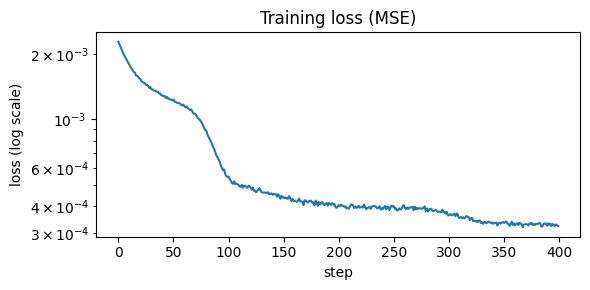

In [122]:
opt = qml.AdamOptimizer(stepsize=adam_stepsize)
loss_history = []

for step in range(n_steps):
    params, loss = opt.step_and_cost(mse_loss, params)
    loss_history.append(float(loss))
    if step % 10 == 0 or step == n_steps - 1:
        _tag = "loss" if smooth_lambda > 0 else "MSE"
        print(f"step {step:4d}  {_tag} {float(loss):.6f}")

ph_final = np.array(circuit_exact(params))
mse_final = float(np.mean((ph_final - p_target) ** 2))
if smooth_lambda > 0:
    sf = float(np.mean((ph_final[1:] - ph_final[:-1]) ** 2))
    print(
        f"Final (exact): MSE={mse_final:.6f}  mean(Δp)²={sf:.6f}  "
        f"total={mse_final + smooth_lambda * sf:.6f}"
    )
else:
    print(f"Final (exact): MSE={mse_final:.6f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(loss_history, lw=1.5)
ax.set_xlabel("step")
ax.set_ylabel("loss (log scale)")
_tl = "Training loss (MSE + λ·smooth)" if smooth_lambda > 0 else "Training loss (MSE)"
ax.set_title(_tl)
plt.tight_layout()
plt.show()

## Target vs learned distribution

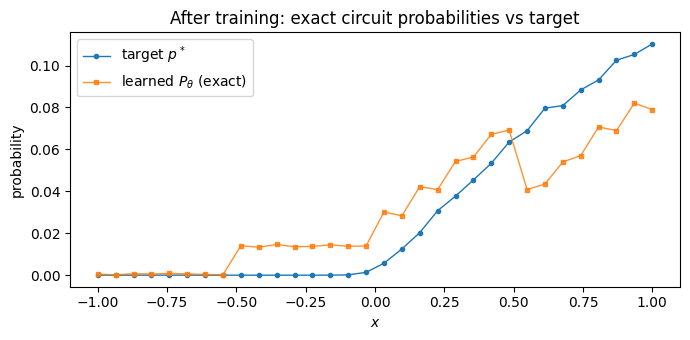

TV distance: 0.23311230811667305


In [123]:
p_learned = np.array(circuit_exact(params))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x_grid, p_target, "o-", ms=3, lw=1, label=r"target $p^*$")
ax.plot(x_grid, p_learned, "s-", ms=3, lw=1, alpha=0.85, label=r"learned $P_\theta$ (exact)")
ax.set_xlabel("$x$")
ax.set_ylabel("probability")
ax.set_title("After training: exact circuit probabilities vs target")
ax.legend()
plt.tight_layout()
plt.show()

print("TV distance:", 0.5 * np.sum(np.abs(p_learned - p_target)))

## Empirical histogram from shots (trained circuit)

`qml.counts` on the same ansatz — compare frequencies to the smooth learned curve.

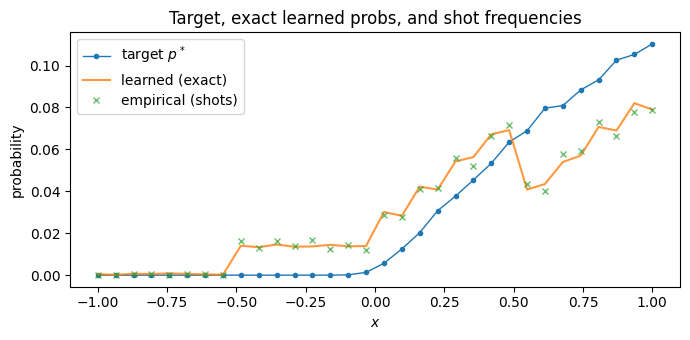

In [124]:
dev_hist = qml.device("default.qubit", wires=n_qubits, shots=8000)


@qml.qnode(dev_hist, diff_method="parameter-shift")
def circuit_counts(p):
    qml.StronglyEntanglingLayers(weights=p, wires=wires)
    return qml.counts()


raw_counts = circuit_counts(params)
p_empirical = counts_to_distribution(raw_counts, n_qubits)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x_grid, p_target, "o-", ms=3, lw=1, label=r"target $p^*$")
ax.plot(x_grid, p_learned, "-", lw=1.5, alpha=0.8, label=r"learned (exact)")
ax.plot(x_grid, p_empirical, "x", ms=4, alpha=0.7, label="empirical (shots)")
ax.set_xlabel("$x$")
ax.set_ylabel("probability")
ax.set_title("Target, exact learned probs, and shot frequencies")
ax.legend()
plt.tight_layout()
plt.show()

## Trained circuit diagram

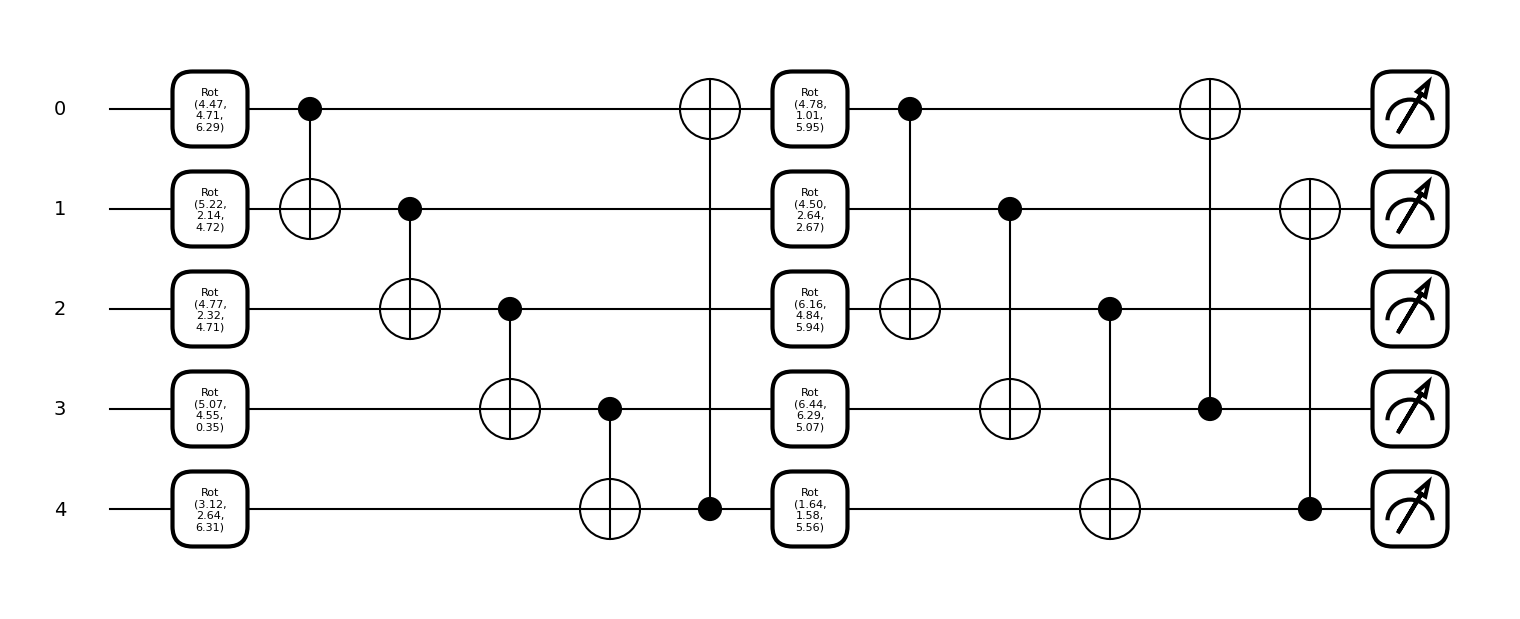

In [125]:
fig, ax = qml.draw_mpl(circuit_exact, decimals=2)(params)
plt.show()